# 🐭 Micromouse Algorithm Analysis
## Flood Fill vs. Incremental A* — Critical Comparative Study

---

This notebook performs a deep, quantitative analysis of simulation log data from a three-phase Micromouse maze-solving competition setup:

| Phase | Name | Description |
|-------|------|-------------|
| **Phase 1** | Exploration | Navigate from start to goal while mapping walls |
| **Phase 2** | Reverse Exploration | Return to start, continuing to map |
| **Phase 3** | Speed Run | Optimal sprint to goal using the now-complete map |

We compare two algorithms:
- **Flood Fill** — Classic, reactive, propagates distance values across the grid
- **Incremental A\*** — Graph-based, uses heuristics and incrementally updates plans on wall discovery

---

> **Research Questions answered in this notebook:**
> 1. How robust is the data pipeline? (JSON parsing, flattening)
> 2. Does Phase 2 genuinely improve map knowledge?
> 3. Does exploring more guarantee a faster sprint?
> 4. Which algorithm has lower computational overhead per sensor event?
> 5. How does turn density evolve across the three phases?
> 6. How sensitive are the algorithms to different maze typologies?
> 7. What characterizes failed runs?

In [ ]:
# ─── Core Imports ─────────────────────────────────────────────────────────────
import io
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from IPython.display import display

warnings.filterwarnings('ignore')

# ─── Global Aesthetics ────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', font_scale=1.15)

plt.rcParams.update({
    'figure.dpi': 130,

    'figure.facecolor': 'white',
    'axes.facecolor': 'white',

    'axes.edgecolor': 'black',
    'axes.labelcolor': 'black',

    'xtick.color': 'black',
    'ytick.color': 'black',

    'text.color': 'black',

    'grid.color': '#D0D0D0',
    'grid.linestyle': '--',
    'grid.alpha': 0.5,

    'legend.facecolor': 'white',
    'legend.edgecolor': '#B0B0B0',

    'font.family': 'DejaVu Sans',
})

# ─── Algorithm Colour Palette ─────────────────────────────────────────────────
ALG_PALETTE = {
    'FloodFill': '#4A90D9',
    'IncrementalAStar': '#E87040',
}
ALG_ORDER = ['FloodFill', 'IncrementalAStar']

print('✅ Imports and theme configured.')

✅ Imports and theme configured.


In [2]:
import sys
print(sys.executable)

/opt/anaconda3/bin/python


---
## Section 1 — Data Preprocessing
### Why this matters
The raw CSV stores the per-phase telemetry as **stringified JSON objects** inside each cell. Before any analysis is possible, we must:
1. Detect and correctly parse these embedded JSON strings (they use `""` as escaped quotes in CSV)
2. Flatten each phase into prefixed columns (`p1_`, `p2_`, `p3_`)
3. Coerce types and handle any malformed / missing records gracefully

**What to look for:** After preprocessing the DataFrame should have ~30+ columns with no unexpected NaN in the phase-prefixed columns (for complete runs), and `reached_goal` should be boolean.

In [3]:
# ─── 1a  Dummy / Fallback Data (immediately runnable) ─────────────────────────
# This mirrors the exact schema produced by the Micromouse simulator.
# The real CSV is loaded below; this data is only used if the file is missing.

DUMMY_CSV = """\
algorithm,maze_name,maze_typology,run_index,visited_cells,total_cells,final_path_length,total_moves,total_turns,elapsed_seconds,replan_count,new_walls_found,reached_goal,notes,exploration_ratio,turn_ratio,moves_per_cell,speedrun_efficiency,phase1,phase2,phase3
FloodFill,maze_a,open_field,0,214,256,90,445,287,29.25,146,146,False,,0.8359,0.3921,2.0794,0.0349,"{""phase_name"": ""Phase1_Exploration"", ""moves"": 324, ""turns"": 224, ""cells_visited"": 209, ""time_seconds"": 22.82, ""walls_found"": 144, ""replan_count"": 144, ""reached_target"": true, ""total_commands"": 548, ""turn_ratio"": 0.4088, ""moves_per_cell"": 1.55}","{""phase_name"": ""Phase2_ReverseExploration"", ""moves"": 106, ""turns"": 58, ""cells_visited"": 3, ""time_seconds"": 5.71, ""walls_found"": 2, ""replan_count"": 2, ""reached_target"": true, ""total_commands"": 164, ""turn_ratio"": 0.3537, ""moves_per_cell"": 35.33}","{""phase_name"": ""SpeedRun"", ""moves"": 15, ""turns"": 5, ""cells_visited"": 1, ""time_seconds"": 0.73, ""walls_found"": 0, ""replan_count"": 0, ""reached_target"": false, ""total_commands"": 20, ""turn_ratio"": 0.25, ""moves_per_cell"": 15.0}"
FloodFill,maze_a,open_field,1,167,256,70,310,147,20.25,133,133,True,,0.6523,0.3217,1.8563,0.2917,"{""phase_name"": ""Phase1_Exploration"", ""moves"": 120, ""turns"": 59, ""cells_visited"": 105, ""time_seconds"": 9.04, ""walls_found"": 84, ""replan_count"": 84, ""reached_target"": true, ""total_commands"": 179, ""turn_ratio"": 0.3296, ""moves_per_cell"": 1.14}","{""phase_name"": ""Phase2_ReverseExploration"", ""moves"": 120, ""turns"": 59, ""cells_visited"": 61, ""time_seconds"": 7.73, ""walls_found"": 49, ""replan_count"": 49, ""reached_target"": true, ""total_commands"": 179, ""turn_ratio"": 0.3296, ""moves_per_cell"": 1.97}","{""phase_name"": ""SpeedRun"", ""moves"": 70, ""turns"": 29, ""cells_visited"": 0, ""time_seconds"": 3.48, ""walls_found"": 0, ""replan_count"": 0, ""reached_target"": true, ""total_commands"": 99, ""turn_ratio"": 0.2929, ""moves_per_cell"": 0.0}"
FloodFill,maze_b,dead_end_heavy,0,213,256,84,324,118,22.46,163,163,True,,0.832,0.267,1.5211,0.35,"{""phase_name"": ""Phase1_Exploration"", ""moves"": 138, ""turns"": 56, ""cells_visited"": 117, ""time_seconds"": 11.28, ""walls_found"": 94, ""replan_count"": 94, ""reached_target"": true, ""total_commands"": 194, ""turn_ratio"": 0.2887, ""moves_per_cell"": 1.18}","{""phase_name"": ""Phase2_ReverseExploration"", ""moves"": 102, ""turns"": 32, ""cells_visited"": 86, ""time_seconds"": 7.07, ""walls_found"": 69, ""replan_count"": 69, ""reached_target"": true, ""total_commands"": 134, ""turn_ratio"": 0.2388, ""moves_per_cell"": 1.19}","{""phase_name"": ""SpeedRun"", ""moves"": 84, ""turns"": 30, ""cells_visited"": 9, ""time_seconds"": 4.11, ""walls_found"": 0, ""replan_count"": 0, ""reached_target"": true, ""total_commands"": 114, ""turn_ratio"": 0.2632, ""moves_per_cell"": 9.33}"
IncrementalAStar,maze_a,open_field,0,193,256,50,228,92,55.65,93,155,False,,0.7539,0.2875,1.1813,0.0654,"{""phase_name"": ""Phase1_Exploration"", ""moves"": 118, ""turns"": 54, ""cells_visited"": 107, ""time_seconds"": 10.68, ""walls_found"": 88, ""replan_count"": 51, ""reached_target"": true, ""total_commands"": 172, ""turn_ratio"": 0.314, ""moves_per_cell"": 1.1}","{""phase_name"": ""Phase2_ReverseExploration"", ""moves"": 96, ""turns"": 32, ""cells_visited"": 83, ""time_seconds"": 6.16, ""walls_found"": 67, ""replan_count"": 42, ""reached_target"": true, ""total_commands"": 128, ""turn_ratio"": 0.25, ""moves_per_cell"": 1.16}","{""phase_name"": ""SpeedRun"", ""moves"": 14, ""turns"": 6, ""cells_visited"": 2, ""time_seconds"": 38.81, ""walls_found"": 0, ""replan_count"": 0, ""reached_target"": false, ""total_commands"": 20, ""turn_ratio"": 0.3, ""moves_per_cell"": 7.0}"
IncrementalAStar,maze_a,open_field,1,175,256,70,320,151,21.46,70,135,True,,0.6836,0.3206,1.8286,0.28,"{""phase_name"": ""Phase1_Exploration"", ""moves"": 176, ""turns"": 93, ""cells_visited"": 131, ""time_seconds"": 13.82, ""walls_found"": 107, ""replan_count"": 58, ""reached_target"": true, ""total_commands"": 269, ""turn_ratio"": 0.3457, ""moves_per_cell"": 1.34}","{""phase_name"": ""Phase2_ReverseExploration"", ""moves"": 74, ""turns"": 29, ""cells_visited"": 37, ""time_seconds"": 4.18, ""walls_found"": 28, ""replan_count"": 12, ""reached_target"": true, ""total_commands"": 103, ""turn_ratio"": 0.2816, ""moves_per_cell"": 2.0}","{""phase_name"": ""SpeedRun"", ""moves"": 70, ""turns"": 29, ""cells_visited"": 6, ""time_seconds"": 3.46, ""walls_found"": 0, ""replan_count"": 0, ""reached_target"": true, ""total_commands"": 99, ""turn_ratio"": 0.2929, ""moves_per_cell"": 11.67}"
IncrementalAStar,maze_a,open_field,2,175,256,70,320,151,19.07,70,135,True,,0.6836,0.3206,1.8286,0.28,"{""phase_name"": ""Phase1_Exploration"", ""moves"": 176, ""turns"": 93, ""cells_visited"": 131, ""time_seconds"": 11.47, ""walls_found"": 107, ""replan_count"": 58, ""reached_target"": true, ""total_commands"": 269, ""turn_ratio"": 0.3457, ""moves_per_cell"": 1.34}","{""phase_name"": ""Phase2_ReverseExploration"", ""moves"": 74, ""turns"": 29, ""cells_visited"": 37, ""time_seconds"": 4.13, ""walls_found"": 28, ""replan_count"": 12, ""reached_target"": true, ""total_commands"": 103, ""turn_ratio"": 0.2816, ""moves_per_cell"": 2.0}","{""phase_name"": ""SpeedRun"", ""moves"": 70, ""turns"": 29, ""cells_visited"": 6, ""time_seconds"": 3.47, ""walls_found"": 0, ""replan_count"": 0, ""reached_target"": true, ""total_commands"": 99, ""turn_ratio"": 0.2929, ""moves_per_cell"": 11.67}"
IncrementalAStar,maze_b,dead_end_heavy,0,168,256,54,281,181,17.59,62,117,False,,0.6562,0.3918,1.6726,0.0485,"{""phase_name"": ""Phase1_Exploration"", ""moves"": 214, ""turns"": 136, ""cells_visited"": 152, ""time_seconds"": 13.91, ""walls_found"": 115, ""replan_count"": 61, ""reached_target"": true, ""total_commands"": 350, ""turn_ratio"": 0.3886, ""moves_per_cell"": 1.41}","{""phase_name"": ""Phase2_ReverseExploration"", ""moves"": 54, ""turns"": 34, ""cells_visited"": 12, ""time_seconds"": 2.95, ""walls_found"": 2, ""replan_count"": 1, ""reached_target"": true, ""total_commands"": 88, ""turn_ratio"": 0.3864, ""moves_per_cell"": 4.5}","{""phase_name"": ""SpeedRun"", ""moves"": 13, ""turns"": 11, ""cells_visited"": 3, ""time_seconds"": 0.72, ""walls_found"": 0, ""replan_count"": 0, ""reached_target"": false, ""total_commands"": 24, ""turn_ratio"": 0.4583, ""moves_per_cell"": 4.33}"
IncrementalAStar,maze_b,dead_end_heavy,1,207,256,88,271,182,20.13,82,142,False,,0.8086,0.4018,1.3092,0.0754,"{""phase_name"": ""Phase1_Exploration"", ""moves"": 134, ""turns"": 90, ""cells_visited"": 117, ""time_seconds"": 11.70, ""walls_found"": 89, ""replan_count"": 51, ""reached_target"": true, ""total_commands"": 224, ""turn_ratio"": 0.4018, ""moves_per_cell"": 1.15}","{""phase_name"": ""Phase2_ReverseExploration"", ""moves"": 118, ""turns"": 82, ""cells_visited"": 88, ""time_seconds"": 7.46, ""walls_found"": 53, ""replan_count"": 31, ""reached_target"": true, ""total_commands"": 200, ""turn_ratio"": 0.41, ""moves_per_cell"": 1.34}","{""phase_name"": ""SpeedRun"", ""moves"": 19, ""turns"": 10, ""cells_visited"": 1, ""time_seconds"": 0.98, ""walls_found"": 0, ""replan_count"": 0, ""reached_target"": false, ""total_commands"": 29, ""turn_ratio"": 0.3448, ""moves_per_cell"": 19.0}"
IncrementalAStar,maze_b,dead_end_heavy,2,207,256,88,271,182,18.06,82,142,False,,0.8086,0.4018,1.3092,0.0754,"{""phase_name"": ""Phase1_Exploration"", ""moves"": 134, ""turns"": 90, ""cells_visited"": 117, ""time_seconds"": 9.60, ""walls_found"": 89, ""replan_count"": 51, ""reached_target"": true, ""total_commands"": 224, ""turn_ratio"": 0.4018, ""moves_per_cell"": 1.15}","{""phase_name"": ""Phase2_ReverseExploration"", ""moves"": 118, ""turns"": 82, ""cells_visited"": 88, ""time_seconds"": 7.49, ""walls_found"": 53, ""replan_count"": 31, ""reached_target"": true, ""total_commands"": 200, ""turn_ratio"": 0.41, ""moves_per_cell"": 1.34}","{""phase_name"": ""SpeedRun"", ""moves"": 19, ""turns"": 10, ""cells_visited"": 1, ""time_seconds"": 0.97, ""walls_found"": 0, ""replan_count"": 0, ""reached_target"": false, ""total_commands"": 29, ""turn_ratio"": 0.3448, ""moves_per_cell"": 19.0}"
"""

print('Dummy data schema defined (9 rows, 2 algorithms, 2 maze typologies).')

Dummy data schema defined (9 rows, 2 algorithms, 2 maze typologies).


In [4]:
# ─── 1b  Robust JSON-Phase Parser ─────────────────────────────────────────────

def parse_phase_json(cell_value: object) -> dict:
    """Safely parse a phase JSON cell that may be:
      - Already a dict (loaded from JSON file directly)
      - A stringified JSON with double-escaped quotes (from CSV)
      - An empty string, None, or NaN
    Returns an empty dict on failure so callers get NaN columns, not crashes.
    """
    if isinstance(cell_value, dict):
        return cell_value
    if not isinstance(cell_value, str) or not cell_value.strip():
        return {}
    try:
        return json.loads(cell_value)
    except json.JSONDecodeError:
        pass
    # CSV-escaped variant: '""' → '"'
    try:
        cleaned = cell_value.replace('""', '"').strip('"')
        return json.loads(cleaned)
    except json.JSONDecodeError:
        pass
    return {}


def flatten_phases(df: pd.DataFrame) -> pd.DataFrame:
    """Expand phase1, phase2, phase3 JSON columns into prefixed flat columns."""
    phase_map = {'phase1': 'p1', 'phase2': 'p2', 'phase3': 'p3'}
    expanded = [df]

    for col, prefix in phase_map.items():
        if col not in df.columns:
            continue
        parsed = df[col].apply(parse_phase_json)
        phase_df = pd.json_normalize(parsed).add_prefix(f'{prefix}_')
        # Drop the raw string/dict column from output
        phase_df.index = df.index
        expanded.append(phase_df)

    result = pd.concat(expanded, axis=1)
    result = result.drop(columns=list(phase_map.keys()), errors='ignore')
    return result


print('Phase parser utilities ready.')

Phase parser utilities ready.


In [5]:
# ─── 1c  Load Real CSV (with graceful fallback to dummy data) ─────────────────

# Search for the most recent benchmark CSV in my_results/
search_paths = [
    
    Path('../logs'),         # run from project root
                          
]

csv_path = None
for base in search_paths:
    candidates = sorted(base.glob('benchmark_*.csv'), reverse=True)
    if candidates:
        csv_path = candidates[0]
        break

if csv_path and csv_path.exists():
    print(f'📂 Loading real data from: {csv_path}')
    raw_df = pd.read_csv(csv_path, dtype=str)
    DATA_SOURCE = str(csv_path)
else:
    print('⚠️  No benchmark CSV found — using embedded dummy data.')
    raw_df = pd.read_csv(io.StringIO(DUMMY_CSV), dtype=str)
    DATA_SOURCE = 'dummy (embedded)'

print(f'   Rows loaded: {len(raw_df)}')
print(f'   Columns    : {list(raw_df.columns)}')

📂 Loading real data from: ../logs/benchmark_20260610_105436.csv
   Rows loaded: 40
   Columns    : ['algorithm', 'algorithm_version', 'maze_name', 'maze_typology', 'run_index', 'visited_cells', 'total_cells', 'final_path_length', 'total_moves', 'total_turns', 'elapsed_seconds', 'replan_count', 'new_walls_found', 'reached_goal', 'notes', 'exploration_ratio', 'turn_ratio', 'moves_per_cell', 'speedrun_efficiency', 'phase1', 'phase2', 'phase3']


In [6]:
# ─── 1d  Flatten & Type-Cast ──────────────────────────────────────────────────

df = flatten_phases(raw_df)

# ── Numeric coercion for all obvious numeric columns ──
numeric_cols = [
    'run_index', 'visited_cells', 'total_cells', 'final_path_length',
    'total_moves', 'total_turns', 'elapsed_seconds', 'replan_count',
    'new_walls_found', 'exploration_ratio', 'turn_ratio', 'moves_per_cell',
    'speedrun_efficiency',
    # phase flattened numerics
    'p1_moves', 'p1_turns', 'p1_cells_visited', 'p1_time_seconds',
    'p1_walls_found', 'p1_replan_count', 'p1_total_commands',
    'p1_turn_ratio', 'p1_moves_per_cell',
    'p2_moves', 'p2_turns', 'p2_cells_visited', 'p2_time_seconds',
    'p2_walls_found', 'p2_replan_count', 'p2_total_commands',
    'p2_turn_ratio', 'p2_moves_per_cell',
    'p3_moves', 'p3_turns', 'p3_cells_visited', 'p3_time_seconds',
    'p3_walls_found', 'p3_replan_count', 'p3_total_commands',
    'p3_turn_ratio', 'p3_moves_per_cell',
]
for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# ── Boolean coercion ──
for col in ['reached_goal', 'p1_reached_target', 'p2_reached_target', 'p3_reached_target']:
    if col in df.columns:
        df[col] = df[col].map(lambda x: str(x).strip().lower() in ('true', '1', 'yes') if pd.notna(x) else False)

# ── Ensure maze_typology column exists (graceful backfill) ──
if 'maze_typology' not in df.columns:
    df['maze_typology'] = 'unknown'
    print("ℹ️  'maze_typology' column not found in CSV — filled with 'unknown'.")
df['maze_typology'] = df['maze_typology'].fillna('unknown').replace('', 'unknown')

# ── Total time (sum of phases) ──
df['total_phase_time'] = df[['p1_time_seconds', 'p2_time_seconds', 'p3_time_seconds']].sum(axis=1, min_count=1)

print(f'\n✅ Final DataFrame shape: {df.shape}')
print(f'   Algorithms: {df["algorithm"].unique()}')
print(f'   Maze names: {df["maze_name"].unique()}')
print(f'   Typologies: {df["maze_typology"].unique()}')
print(f'\n--- Summary ---')
display(df[['algorithm', 'maze_name', 'maze_typology', 'reached_goal',
            'elapsed_seconds', 'exploration_ratio', 'speedrun_efficiency']].to_string())


✅ Final DataFrame shape: (40, 53)
   Algorithms: ['FloodFill' 'IncrementalAStar']
   Maze names: ['1_competition' '2_competition' '3_competition' '4_competition'
 '5_competition' '6_competition' '7_competition' '8_competition'
 '9_dead_end' '10_dead_end' '11_dead_end' '12_multiple_path'
 '13_multiple_path' '14_multiple_path' '15_open_area' '16_open_area'
 '17_open_area' '18_symmetric' '19_symmetric' '20_symmetric']
   Typologies: ['competition' 'dead_end' 'multiple_path' 'open_area' 'symmetric']

--- Summary ---


'           algorithm         maze_name  maze_typology  reached_goal  elapsed_seconds  exploration_ratio  speedrun_efficiency\n0          FloodFill     1_competition    competition          True          23.4851             0.5234               0.3448\n1          FloodFill     2_competition    competition          True          38.5441             0.7969               0.3796\n2          FloodFill     3_competition    competition          True          38.2595             0.8750               0.3125\n3          FloodFill     4_competition    competition          True          26.5208             0.5859               0.3143\n4          FloodFill     5_competition    competition          True          32.4049             0.6758               0.2461\n5          FloodFill     6_competition    competition          True          19.9478             0.3516               0.4122\n6          FloodFill     7_competition    competition          True          43.8297             0.7266              

In [7]:
# ─── 1e  Schema Summary ───────────────────────────────────────────────────────
print(f'Total columns after flattening: {len(df.columns)}\n')
summary = pd.DataFrame({
    'dtype': df.dtypes,
    'non_null': df.notna().sum(),
    'null': df.isna().sum(),
    'null_%': (df.isna().mean() * 100).round(1),
})
display(summary)

Total columns after flattening: 53



,dtype,non_null,null,null_%
algorithm,object,40,0,0.0
algorithm_version,object,40,0,0.0
maze_name,object,40,0,0.0
maze_typology,object,40,0,0.0
run_index,int64,40,0,0.0
visited_cells,int64,40,0,0.0
total_cells,int64,40,0,0.0
final_path_length,int64,40,0,0.0
total_moves,int64,40,0,0.0
total_turns,int64,40,0,0.0


---
## Section 2 — Phase 2 Efficiency: Return-Run Overhead
### Why this matters
Phase 2 is a *deliberate* investment: the robot navigates back to start, spending time and moves, with the expectation of discovering more walls for a better SpeedRun map. The key questions are:

- **Does Phase 2 actually find new walls?** Compare `p2_walls_found` against `p1_walls_found`.
- **Is the time cost proportional?** The **Return-Overhead Index (ROI-t)** = `p2_time / p1_time`. A value < 0.5 means Phase 2 is cheap relative to exploration.

**What to look for:** Flood Fill may have a higher Phase 2 wall-discovery rate (since it replans globally on every wall), while A* might front-load more discovery in Phase 1 due to smarter routing.

In [8]:
# ─── 2a  Walls Found Comparison ───────────────────────────────────────────────
walls_data = (
    df.groupby('algorithm')[['p1_walls_found', 'p2_walls_found']]
      .mean()
      .round(2)
)
print('Mean walls found per phase, by algorithm:')
display(walls_data)

# Incremental discovery ratio
walls_data['p2_vs_p1_%'] = (walls_data['p2_walls_found'] / walls_data['p1_walls_found'] * 100).round(1)
print('\nPhase 2 discovers this % of Phase 1 wall count (on average):')
display(walls_data[['p2_vs_p1_%']])

Mean walls found per phase, by algorithm:


,p1_walls_found,p2_walls_found
algorithm,,
FloodFill,77.70,27.25
IncrementalAStar,82.65,23.95



Phase 2 discovers this % of Phase 1 wall count (on average):


,p2_vs_p1_%
algorithm,
FloodFill,35.1
IncrementalAStar,29.0


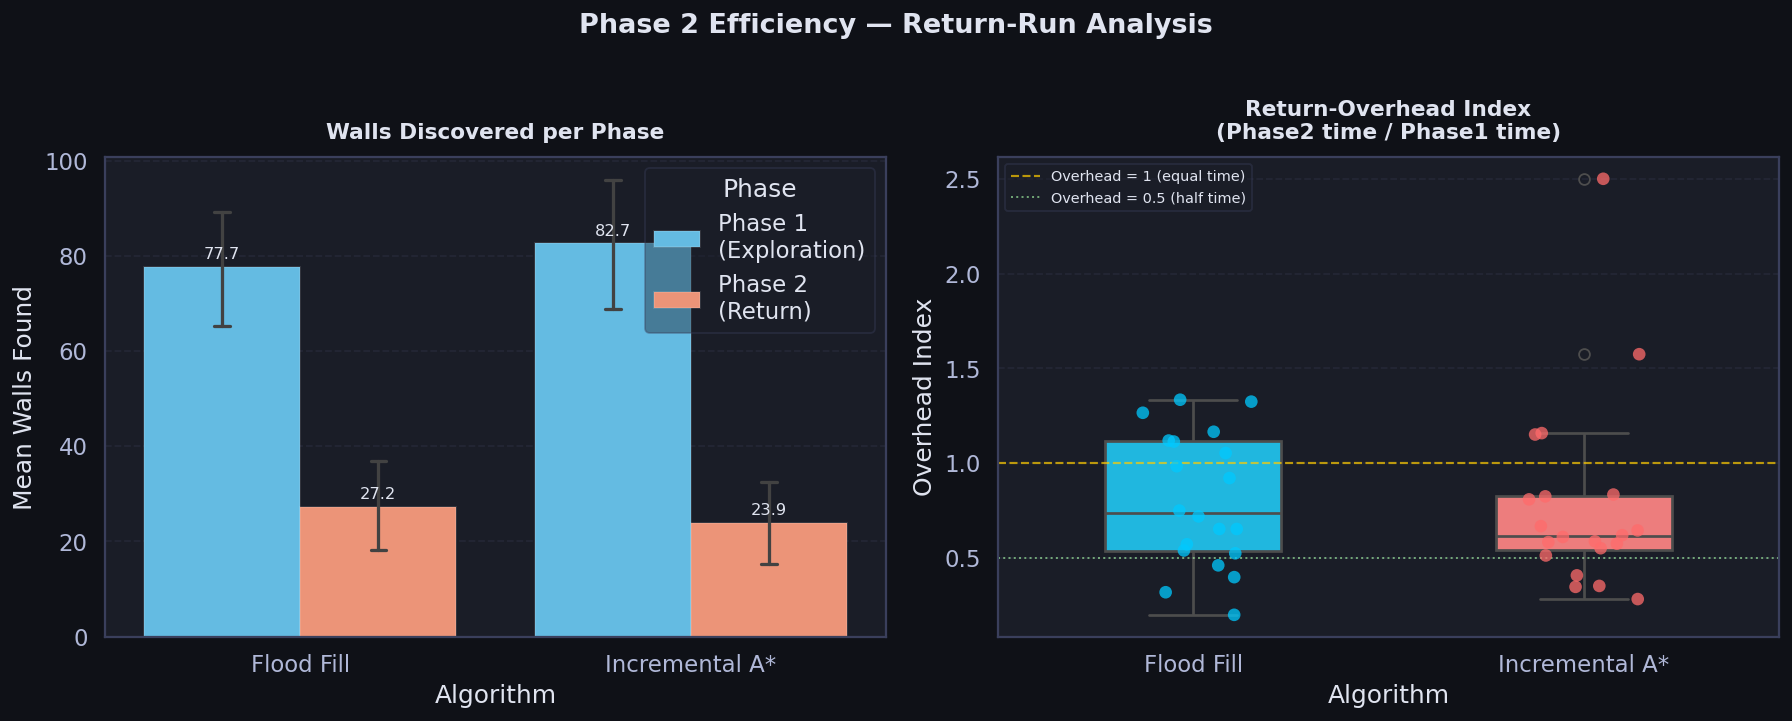


Interpretation: A lower Return-Overhead Index means Phase 2 is cheaper relative to Phase 1.


In [ ]:
# ─── 2b  Return-Overhead Index + Grouped Bar Chart ────────────────────────────
df['return_overhead_idx'] = df['p2_time_seconds'] / df['p1_time_seconds'].replace(0, np.nan)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
fig.suptitle('Phase 2 Efficiency — Return-Run Analysis', fontsize=15, fontweight='bold', y=1.01)

# ── Left: Walls found P1 vs P2 side-by-side ──
ax = axes[0]
melt_walls = df.melt(
    id_vars='algorithm',
    value_vars=['p1_walls_found', 'p2_walls_found'],
    var_name='phase', value_name='walls_found'
)
melt_walls['phase'] = melt_walls['phase'].map({
    'p1_walls_found': 'Phase 1\n(Exploration)',
    'p2_walls_found': 'Phase 2\n(Return)'
})

phase_palette = {
    'Phase 1\n(Exploration)': '#4A90D9',
    'Phase 2\n(Return)': '#E87040'
}
sns.barplot(
    data=melt_walls, x='algorithm', y='walls_found', hue='phase',
    palette=phase_palette, ax=ax, capsize=0.08, errwidth=1.8,
    edgecolor='#ffffff20'
)
ax.set_title('Walls Discovered per Phase', fontsize=12, fontweight='bold', pad=10)
ax.set_xlabel('Algorithm')
ax.set_ylabel('Mean Walls Found')
ax.set_xticklabels(['Flood Fill', 'Incremental A*'])
ax.legend(title='Phase', framealpha=0.4)

# Annotate bars with values
for p in ax.patches:
    h = p.get_height()
    if h > 0:
        ax.text(p.get_x() + p.get_width() / 2, h + 1, f'{h:.1f}',
                ha='center', va='bottom', fontsize=9, color='#e0e4f0')

# ── Right: Return-Overhead Index distribution ──
ax2 = axes[1]
sns.boxplot(
    data=df, x='algorithm', y='return_overhead_idx',
    palette=ALG_PALETTE, order=ALG_ORDER, ax=ax2,
    width=0.45, linewidth=1.5, flierprops=dict(marker='o', color='#ffcc00', markersize=6)
)
sns.stripplot(
    data=df, x='algorithm', y='return_overhead_idx',
    palette=ALG_PALETTE, order=ALG_ORDER, ax=ax2,
    size=7, alpha=0.75, jitter=0.15
)
ax2.axhline(1.0, color='#ffcc00', linestyle='--', linewidth=1.2, alpha=0.7, label='Overhead = 1 (equal time)')
ax2.axhline(0.5, color='#aaffaa', linestyle=':', linewidth=1.1, alpha=0.6, label='Overhead = 0.5 (half time)')
ax2.set_title('Return-Overhead Index\n(Phase2 time / Phase1 time)', fontsize=12, fontweight='bold', pad=10)
ax2.set_xlabel('Algorithm')
ax2.set_ylabel('Overhead Index')
ax2.set_xticklabels(['Flood Fill', 'Incremental A*'])
ax2.legend(fontsize=8, framealpha=0.4)

plt.tight_layout()
plt.savefig('phase2_efficiency.png', dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print('\nInterpretation: A lower Return-Overhead Index means Phase 2 is cheaper relative to Phase 1.')

---
## Section 3 — Exploration ROI: Does More Exploration Mean a Faster Sprint?
### Why this matters
It seems intuitive that exploring more of the maze (higher `exploration_ratio`) leads to a better map and therefore a faster SpeedRun (`p3_time_seconds`). But is this actually true?

Counter-hypothesis: over-exploration may mean the robot visits dead-ends and wastes time, while an algorithmically smarter strategy might find the optimal path with a *lower* exploration ratio.

**What to look for:** A negative correlation (top-left cluster) would confirm that more exploration helps. Scattered / positive correlations would suggest the algorithm's path quality matters more than sheer coverage.

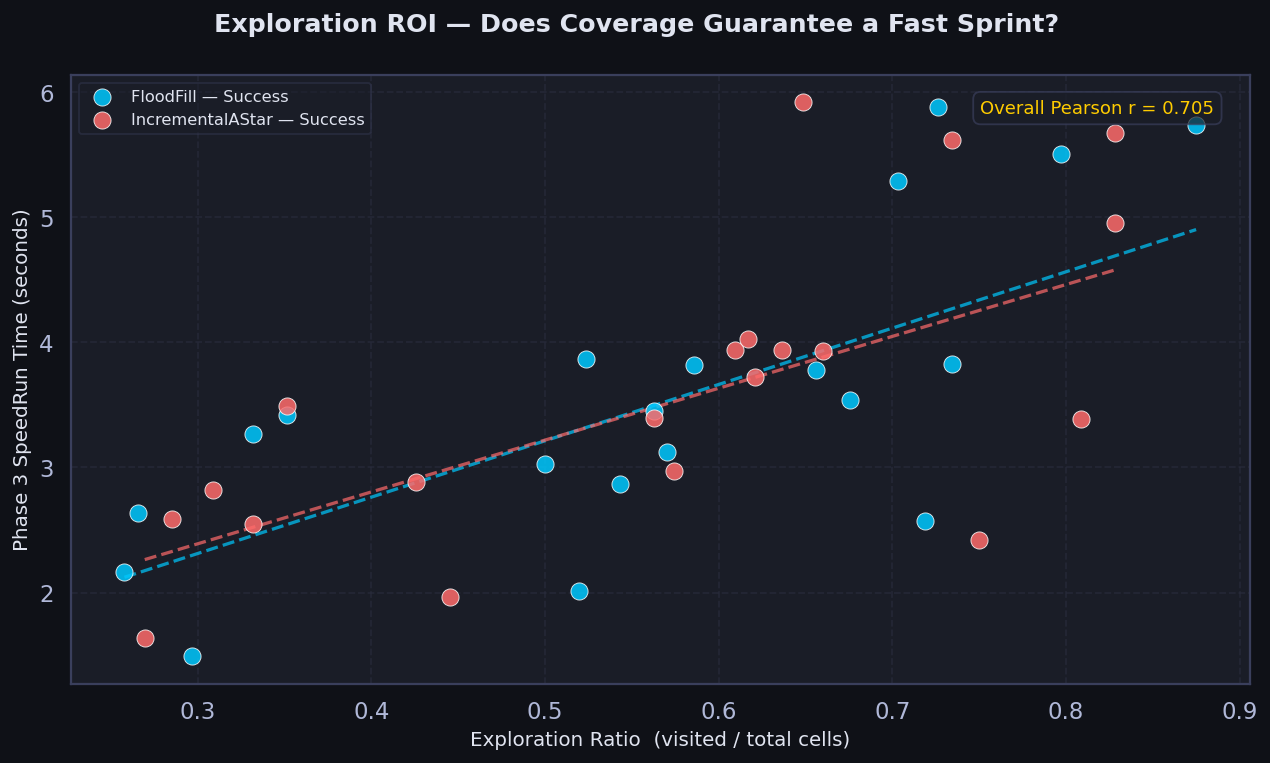


Pearson correlation (exploration_ratio vs p3_time_seconds) per algorithm:
  FloodFill           : r = 0.7324
  IncrementalAStar    : r = 0.6773


In [ ]:
# ─── 3  Exploration ROI Scatter Plot ──────────────────────────────────────────
plot_df = df.dropna(subset=['exploration_ratio', 'p3_time_seconds']).copy()

# Flag successful SpeedRuns
plot_df['sprint_success'] = plot_df.get('p3_reached_target', pd.Series(False, index=plot_df.index))

fig, ax = plt.subplots(figsize=(10, 6))
fig.suptitle('Exploration ROI — Does Coverage Guarantee a Fast Sprint?',
             fontsize=14, fontweight='bold')

for alg, grp in plot_df.groupby('algorithm'):
    color = ALG_PALETTE.get(alg, '#aaaaaa')
    # Successful runs = filled marker, failures = ×
    succ = grp[grp['sprint_success'] == True]
    fail = grp[grp['sprint_success'] == False]

    ax.scatter(succ['exploration_ratio'], succ['p3_time_seconds'],
               color=color, s=90, alpha=0.85, edgecolors='white', linewidths=0.5,
               zorder=3, label=f'{alg} — Success')

    # Trend line (ignore failures with extreme outlier times)
    trend_data = grp[grp['p3_time_seconds'] < grp['p3_time_seconds'].quantile(0.95)]
    if len(trend_data) >= 2:
        z = np.polyfit(trend_data['exploration_ratio'], trend_data['p3_time_seconds'], 1)
        xr = np.linspace(trend_data['exploration_ratio'].min(), trend_data['exploration_ratio'].max(), 50)
        ax.plot(xr, np.polyval(z, xr), color=color, linewidth=1.8, linestyle='--', alpha=0.7)

# Pearson correlation annotation
if len(plot_df) >= 3:
    corr = plot_df['exploration_ratio'].corr(plot_df['p3_time_seconds'])
    ax.text(
        0.97,
        0.05,
        f'Overall Pearson r = {corr:.3f}',
        transform=ax.transAxes,
        ha='right',
        va='bottom',
        fontsize=10,
        color='#E87040',
        bbox=dict(
            boxstyle='round,pad=0.4',
            facecolor='white',
            edgecolor='#E87040',
            alpha=0.9
        )
    )

ax.set_xlabel('Exploration Ratio  (visited / total cells)', fontsize=11)
ax.set_ylabel('Phase 3 SpeedRun Time (seconds)', fontsize=11)
ax.legend(fontsize=9, framealpha=0.4, loc='upper left')
plt.tight_layout()
plt.savefig('exploration_roi.png', dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

# Per-algorithm correlation
print('\nPearson correlation (exploration_ratio vs p3_time_seconds) per algorithm:')
for alg, grp in plot_df.groupby('algorithm'):
    if len(grp) >= 2:
        r = grp['exploration_ratio'].corr(grp['p3_time_seconds'])
        print(f'  {alg:<20}: r = {r:.4f}')

---
## Section 4 — Replan Intensity & Computational Overhead
### Why this matters
Physical Micromouse hardware runs on microcontrollers (often ARM Cortex-M or similar). Every replan consumes CPU cycles. A key efficiency question is: **for every new wall the sensor finds, how many times does the algorithm replan?**

- **Flood Fill** recalculates the entire distance gradient on every wall discovery → `replan_count ≈ new_walls_found`
- **Incremental A\*** should reuse cached graph data and replan only when the current path is invalidated → `replan_count < new_walls_found`

The **Replan-per-Wall ratio** (RPW) = `replan_count / new_walls_found` is the metric to compare. A lower RPW means less computational waste.

**What to look for:** Incremental A* should have RPW < 1.0. Flood Fill is expected to be near 1.0 (it replans for every wall by design).

Mean Replan-per-Wall (RPW) — lower is more computationally efficient:


rpw_overall                 rpw_phase1                
                        mean  median     std       mean  median     std
algorithm                                                              
FloodFill             1.0000  1.0000  0.0000     1.0000  1.0000  0.0000
IncrementalAStar      0.6359  0.6177  0.0823     0.6485  0.6452  0.0947

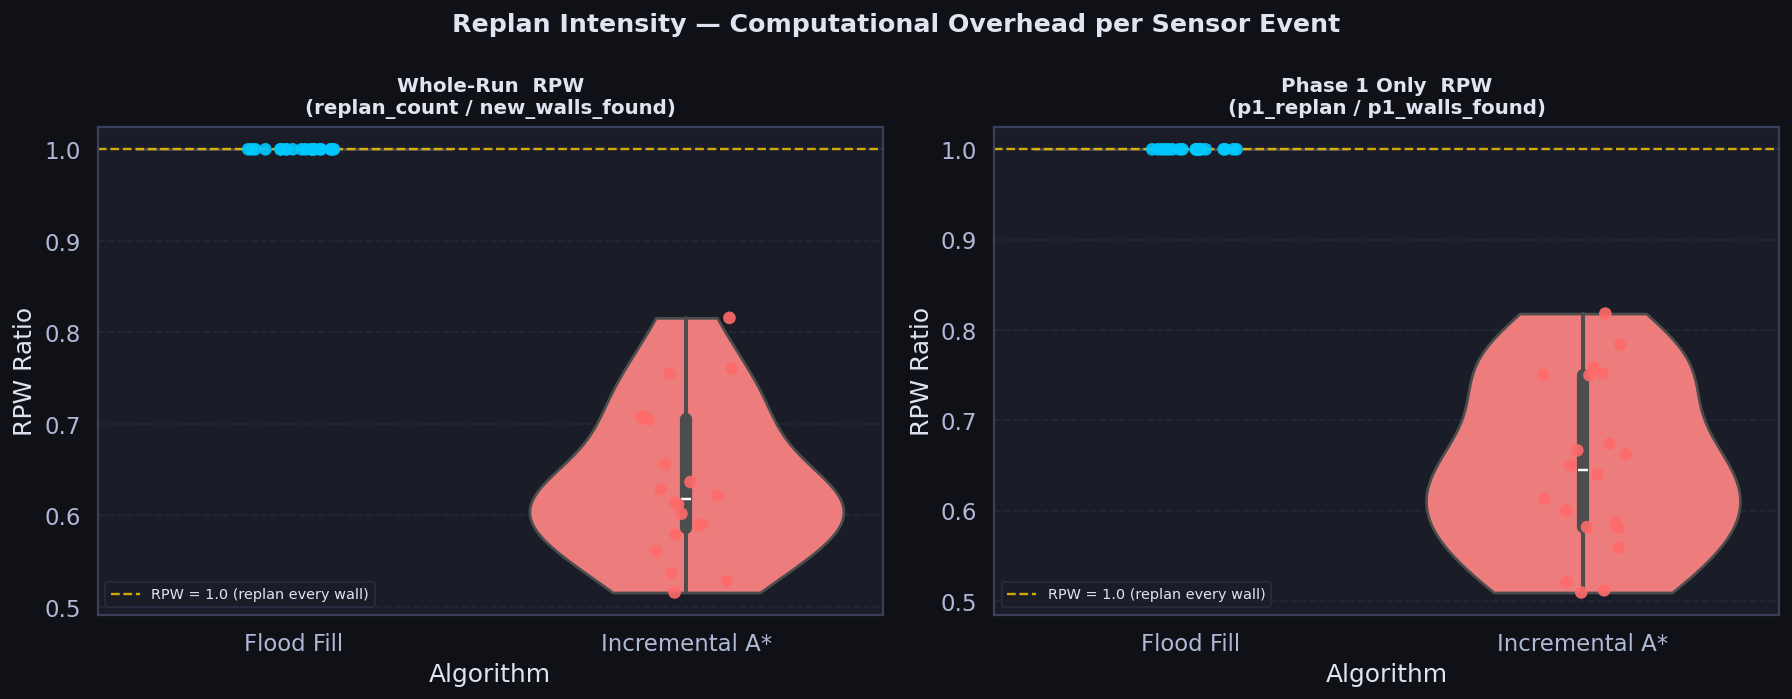

In [11]:
# ─── 4  Replan Intensity ──────────────────────────────────────────────────────

# Overall RPW
df['rpw_overall'] = df['replan_count'] / df['new_walls_found'].replace(0, np.nan)

# Phase-1 specific RPW
df['rpw_phase1'] = df['p1_replan_count'] / df['p1_walls_found'].replace(0, np.nan)

print('Mean Replan-per-Wall (RPW) — lower is more computationally efficient:')
display(df.groupby('algorithm')[['rpw_overall', 'rpw_phase1']].agg(['mean', 'median', 'std']).round(4))

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
fig.suptitle('Replan Intensity — Computational Overhead per Sensor Event', fontsize=14, fontweight='bold')

for i, (col, title) in enumerate([
    ('rpw_overall', 'Whole-Run  RPW\n(replan_count / new_walls_found)'),
    ('rpw_phase1',  'Phase 1 Only  RPW\n(p1_replan / p1_walls_found)'),
]):
    ax = axes[i]
    plot_data = df.dropna(subset=[col])

    sns.violinplot(
        data=plot_data, x='algorithm', y=col,
        palette=ALG_PALETTE, order=ALG_ORDER, ax=ax,
        inner='box', cut=0, linewidth=1.5
    )
    sns.stripplot(
        data=plot_data, x='algorithm', y=col,
        palette=ALG_PALETTE, order=ALG_ORDER, ax=ax,
        size=7, alpha=0.9, jitter=0.12, zorder=3
    )
    ax.axhline(1.0, color='#ffcc00', linestyle='--', linewidth=1.3, alpha=0.8, label='RPW = 1.0 (replan every wall)')
    ax.set_title(title, fontsize=11, fontweight='bold', pad=8)
    ax.set_xlabel('Algorithm')
    ax.set_ylabel('RPW Ratio')
    ax.set_xticklabels(['Flood Fill', 'Incremental A*'])
    ax.legend(fontsize=8, framealpha=0.4)

plt.tight_layout()
plt.savefig('replan_intensity.png', dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

---
## Section 5 — Kinematic Smoothness: Turn Density Across Phases
### Why this matters
On a physical Micromouse, **turns are expensive**: they require deceleration, rotation, and re-acceleration. A lower `turn_ratio` (turns / total_commands) means a geometrically smoother path, which translates to higher real-world speed.

We expect the turn ratio to **drop sharply in Phase 3** (SpeedRun) because at that point the algorithm navigates using the complete map and can choose the globally optimal, straight-line-biased path.

**What to look for:** A V-shape or decreasing staircase from P1 → P3 confirms path quality improvement. A flat or increasing trend suggests the algorithm fails to use map knowledge to smooth its route.

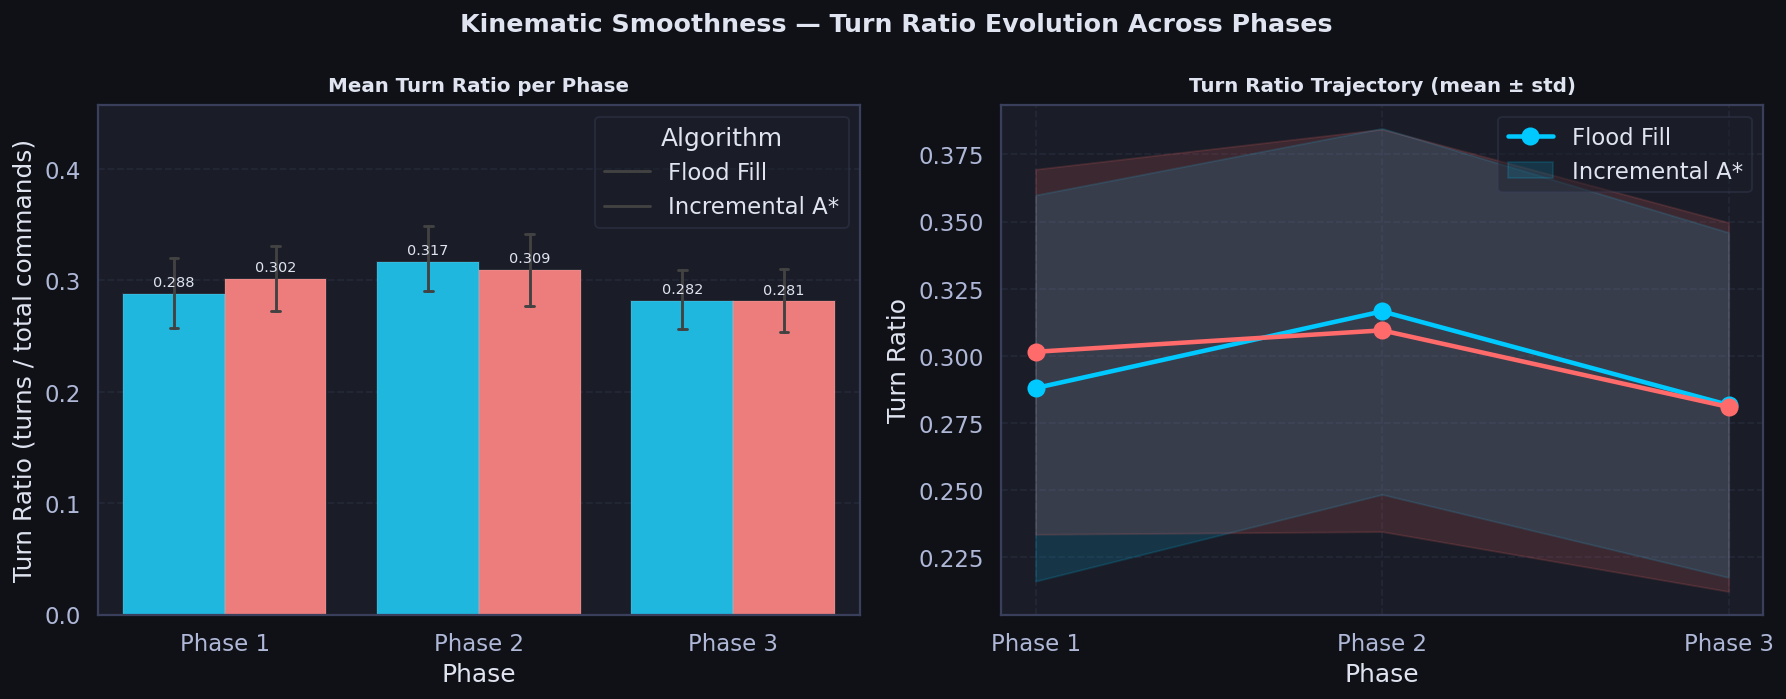


Mean turn_ratio per algorithm per phase:


phase,Phase 1,Phase 2,Phase 3
algorithm,,,
FloodFill,0.2880,0.3166,0.2817
IncrementalAStar,0.3015,0.3095,0.2810


In [ ]:
# ─── 5  Turn Ratio Evolution Across Phases ────────────────────────────────────
turn_cols = {'Phase 1': 'p1_turn_ratio', 'Phase 2': 'p2_turn_ratio', 'Phase 3': 'p3_turn_ratio'}

# Prepare long-form data
turn_long = []
for phase_label, col in turn_cols.items():
    if col in df.columns:
        subset = df[['algorithm', col]].dropna()
        subset = subset.rename(columns={col: 'turn_ratio'})
        subset['phase'] = phase_label
        turn_long.append(subset)

turn_df = pd.concat(turn_long, ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
fig.suptitle('Kinematic Smoothness — Turn Ratio Evolution Across Phases', fontsize=14, fontweight='bold')

# ── Left: Grouped bar chart ──
ax = axes[0]
phase_order = ['Phase 1', 'Phase 2', 'Phase 3']

sns.barplot(
    data=turn_df, x='phase', y='turn_ratio', hue='algorithm',
    order=phase_order, hue_order=ALG_ORDER, palette=ALG_PALETTE,
    ax=ax, capsize=0.07, errwidth=1.6, edgecolor='#ffffff15'
)
ax.set_title('Mean Turn Ratio per Phase', fontsize=11, fontweight='bold', pad=8)
ax.set_xlabel('Phase')
ax.set_ylabel('Turn Ratio (turns / total commands)')
ax.set_ylim(0, ax.get_ylim()[1] * 1.25)
ax.legend(title='Algorithm', labels=['Flood Fill', 'Incremental A*'], framealpha=0.4)
for p in ax.patches:
    h = p.get_height()
    if h > 0.001:
        ax.annotate(
            f'{h:.3f}',
            xy=(
                p.get_x() + p.get_width()/2,
                h
            ),
            xytext=(4,4),
            textcoords='offset points',
            ha='left',
            va='bottom',
            fontsize=8,
            color='black'
        )

# ── Right: Line plot showing individual run trajectories ──
ax2 = axes[1]
phase_numeric = {'Phase 1': 1, 'Phase 2': 2, 'Phase 3': 3}
turn_df['phase_n'] = turn_df['phase'].map(phase_numeric)

for alg, grp in turn_df.groupby('algorithm'):
    color = ALG_PALETTE.get(alg, '#aaaaaa')
    means = grp.groupby('phase_n')['turn_ratio'].mean()
    stds = grp.groupby('phase_n')['turn_ratio'].std().fillna(0)
    x = means.index.values
    y = means.values
    e = stds.values

    ax2.plot(x, y, marker='o', color=color, linewidth=2.5, markersize=9,
             label=f'{alg}', zorder=3)
    ax2.fill_between(x, y - e, y + e, color=color, alpha=0.15)

ax2.set_xticks([1, 2, 3])
ax2.set_xticklabels(['Phase 1', 'Phase 2', 'Phase 3'])
ax2.set_title('Turn Ratio Trajectory (mean ± std)', fontsize=11, fontweight='bold', pad=8)
ax2.set_xlabel('Phase')
ax2.set_ylabel('Turn Ratio')
ax2.legend(labels=['Flood Fill', 'Incremental A*'], framealpha=0.4)

plt.tight_layout()
plt.savefig('kinematic_smoothness.png', dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

# Numeric summary
print('\nMean turn_ratio per algorithm per phase:')
display(turn_df.groupby(['algorithm', 'phase'])['turn_ratio'].mean().unstack().round(4))

---
## Section 6 — Maze Typology Sensitivity
### Why this matters
Different maze structures present fundamentally different challenges:

- **Open fields**: Few walls, many open corridors → pathfinding is fast but robots may miss shortcuts
- **Dead-end heavy**: Many false paths → high backtrack cost, tests replan quality
- **Long corridors**: Straight runs with few junctions → favours algorithms that plan straight-line paths

By grouping on `maze_typology` × `algorithm` we can see whether algorithm performance is **consistent** across maze types or whether one algorithm has a specific strength/weakness.

**What to look for:** High variance across typologies indicates an algorithm is brittle and maze-structure-dependent.

In [13]:
# ─── 6a  Typology Summary Table ───────────────────────────────────────────────
typology_table = (
    df.groupby(['maze_typology', 'algorithm'])
      .agg(
          n_runs=('elapsed_seconds', 'count'),
          success_rate=('reached_goal', 'mean'),
          avg_total_time=('elapsed_seconds', 'mean'),
          avg_visited_cells=('visited_cells', 'mean'),
          avg_exploration_ratio=('exploration_ratio', 'mean'),
          avg_speedrun_eff=('speedrun_efficiency', 'mean'),
          avg_p3_time=('p3_time_seconds', 'mean'),
      )
      .round(3)
)

print('📊 Maze Typology × Algorithm Performance Summary:')
display(typology_table)

📊 Maze Typology × Algorithm Performance Summary:


n_runs  success_rate  avg_total_time  \
maze_typology algorithm                                                
competition   FloodFill              8           1.0          32.031   
              IncrementalAStar       8           1.0          28.863   
dead_end      FloodFill              3           1.0          28.102   
              IncrementalAStar       3           1.0          23.720   
multiple_path FloodFill              3           1.0          24.090   
              IncrementalAStar       3           1.0          28.237   
open_area     FloodFill              3           1.0          12.932   
              IncrementalAStar       3           1.0          13.839   
symmetric     FloodFill              3           1.0          21.543   
              IncrementalAStar       3           1.0          21.453   

                                avg_visited_cells  avg_exploration_ratio  \
maze_typology algorithm                                                    
competition   FloodFill                   166.125                  0.649   
              IncrementalAStar            156.125                  0.610   
dead_end      FloodFill                   166.667                  0.651   
              IncrementalAStar            144.667                  0.565   
multiple_path FloodFill                   136.333                  0.533   
              IncrementalAStar            187.667                  0.733   
open_area     FloodFill                    70.000                  0.273   
              IncrementalAStar             75.667                  0.296   
symmetric     FloodFill                   139.333                  0.544   
              IncrementalAStar            139.667                  0.546   

                                avg_speedrun_eff  avg_p3_time  
maze_typology algorithm                                        
competition   FloodFill                    0.321        4.444  
              IncrementalAStar             0.337        4.397  
dead_end      FloodFill                    0.256        3.141  
              IncrementalAStar             0.292        3.060  
multiple_path FloodFill                    0.368        4.001  
              IncrementalAStar             0.277        3.910  
open_area     FloodFill                    0.387        2.098  
              IncrementalAStar             0.337        2.259  
symmetric     FloodFill                    0.270        2.668  
              IncrementalAStar             0.288        2.988

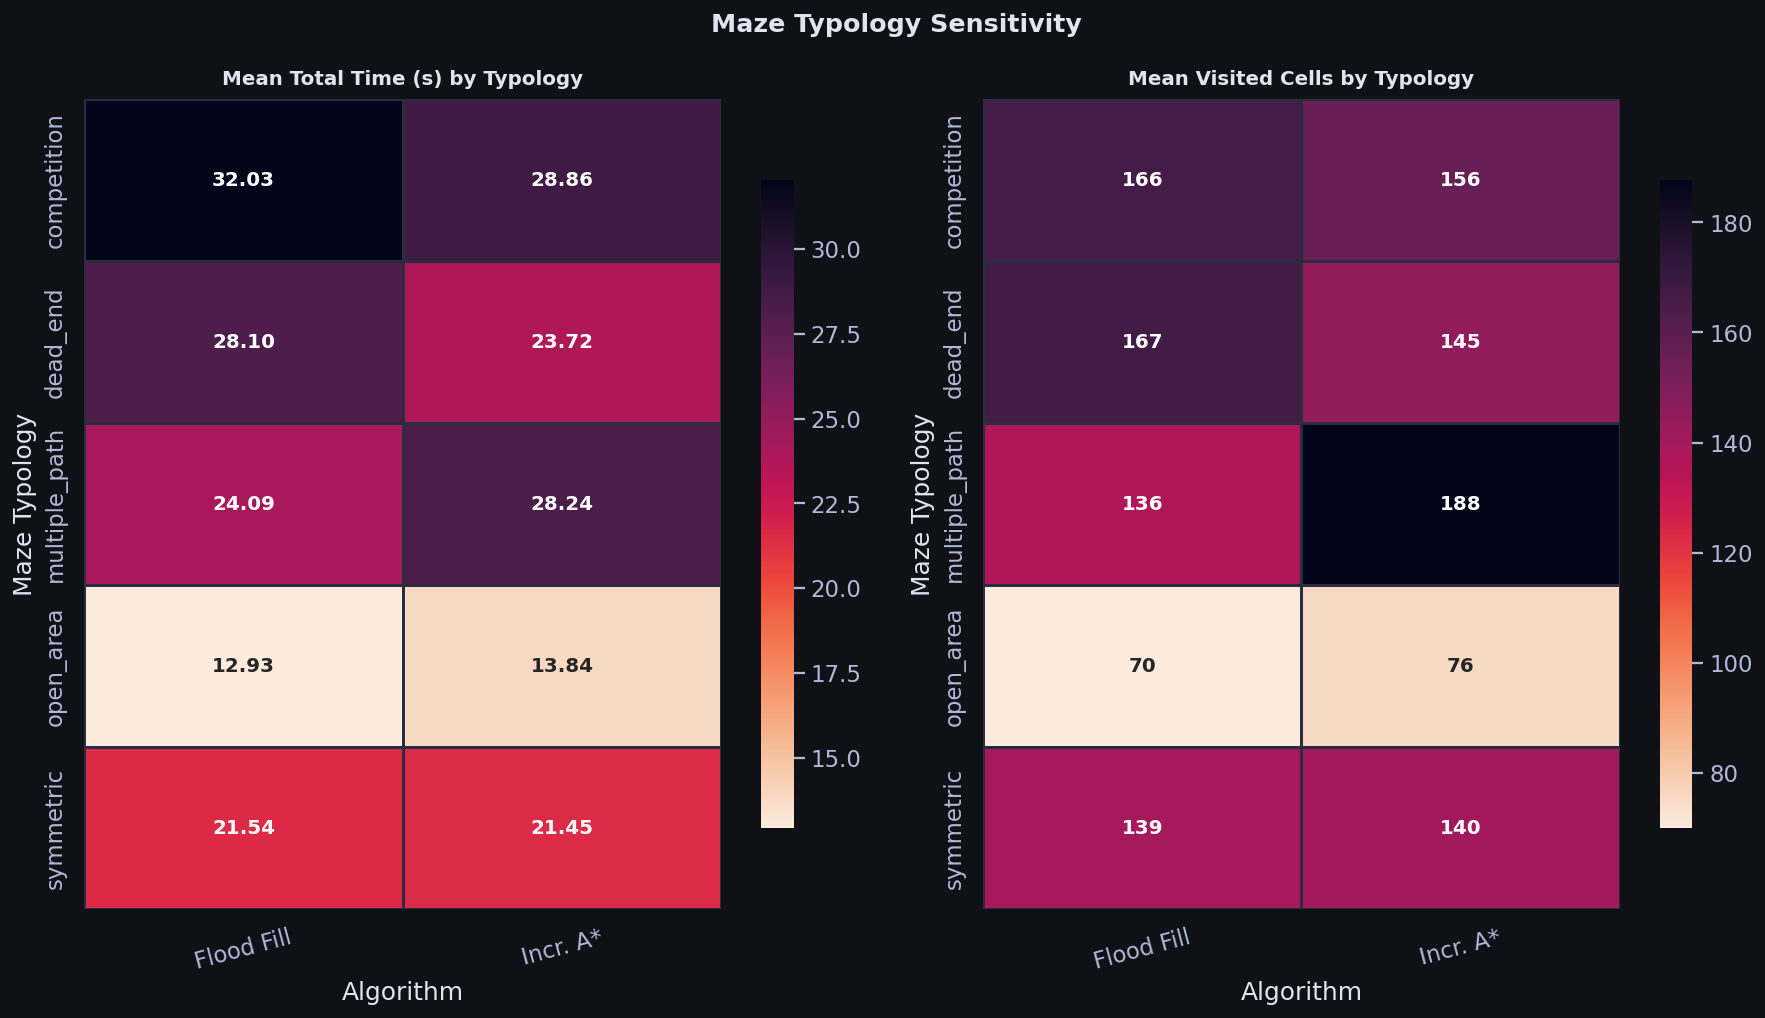

In [ ]:
# ─── 6b  Heatmap: Total Time by Typology × Algorithm ─────────────────────────
pivot_time = (
    df.groupby(['maze_typology', 'algorithm'])['elapsed_seconds']
      .mean()
      .unstack('algorithm')
)

pivot_visited = (
    df.groupby(['maze_typology', 'algorithm'])['visited_cells']
      .mean()
      .unstack('algorithm')
)

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
fig.suptitle('Maze Typology Sensitivity', fontsize=14, fontweight='bold')

cmap = sns.light_palette(
    "#4A90D9",
    as_cmap=True
)

for ax, pivot, title, fmt in zip(
    axes,
    [pivot_time, pivot_visited],
    ['Mean Total Time (s) by Typology', 'Mean Visited Cells by Typology'],
    ['.2f', '.0f'],
):
    mask = pivot.isna()
    sns.heatmap(
        pivot, ax=ax, annot=True, fmt=fmt, cmap=cmap,
        linewidths=0.8, linecolor='#2a2d3e',
        cbar_kws={'shrink': 0.8},
        mask=mask,
        annot_kws={'size': 11, 'weight': 'bold'}
    )
    ax.set_title(title, fontsize=11, fontweight='bold', pad=8)
    ax.set_xlabel('Algorithm')
    ax.set_ylabel('Maze Typology')
    ax.set_xticklabels(['Flood Fill', 'Incr. A*'] if 'FloodFill' in pivot.columns else pivot.columns,
                       rotation=15)

plt.tight_layout()
plt.savefig('typology_sensitivity.png', dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

---
## Section 7 — Failure Mode Profiling
### Why this matters
Understanding *how* an algorithm fails is as important as knowing *if* it fails. In competition Micromouse, failure modes include:

1. **Timeout / excessive time** — the robot kept running but took too long in Phase 3 (often due to a sub-optimal or looping path)
2. **Wrong path** — the SpeedRun navigated to the wrong cell or got stuck early
3. **Loop trap** — high turn count relative to moves in Phase 3 suggests oscillation

We filter for `reached_goal == False` **or** `p3_reached_target == False` and inspect the key discriminating metrics.

**What to look for:** Outlier `p3_time_seconds`, very low `p3_moves`, or high `p3_turn_ratio` compared to successful runs.

In [15]:
# ─── 7a  Identify Failures ────────────────────────────────────────────────────
fail_mask = ~df['reached_goal']
if 'p3_reached_target' in df.columns:
    fail_mask = fail_mask | ~df['p3_reached_target'].fillna(False)

success_mask = ~fail_mask

failures = df[fail_mask].copy()
successes = df[success_mask].copy()

print(f'Total runs   : {len(df)}')
print(f'Failures     : {len(failures)}  ({len(failures)/len(df)*100:.1f}%)')
print(f'Successes    : {len(successes)}  ({len(successes)/len(df)*100:.1f}%)')

print('\n--- Failure distribution by algorithm ---')
display(failures.groupby('algorithm').size().rename('failure_count').to_frame())

Total runs   : 40
Failures     : 0  (0.0%)
Successes    : 40  (100.0%)

--- Failure distribution by algorithm ---


,failure_count
algorithm,


In [16]:
# ─── 7b  Failure Profile Detail Table ────────────────────────────────────────
failure_cols = [
    'algorithm', 'maze_name', 'maze_typology', 'run_index',
    'reached_goal', 'elapsed_seconds',
    'p1_time_seconds', 'p1_walls_found', 'p1_replan_count',
    'p2_time_seconds', 'p2_walls_found',
    'p3_time_seconds', 'p3_moves', 'p3_turns', 'p3_turn_ratio',
    'exploration_ratio', 'speedrun_efficiency',
]
avail_cols = [c for c in failure_cols if c in df.columns]

print('\n🔴 Failure Profiles:')
if len(failures) > 0:
    display(failures[avail_cols].reset_index(drop=True))
else:
    print('No failures detected in this dataset — all runs reached the goal!')


🔴 Failure Profiles:
No failures detected in this dataset — all runs reached the goal!



Mean metrics — Failures vs Successes:


,Phase3 Time (s),Phase3 Turn Ratio,Exploration Ratio,SpeedRun Efficiency,RPW Phase 1
outcome,,,,,
Failure,NaN,NaN,NaN,NaN,NaN
Success,3.5774,0.2813,0.5623,0.3172,0.8242


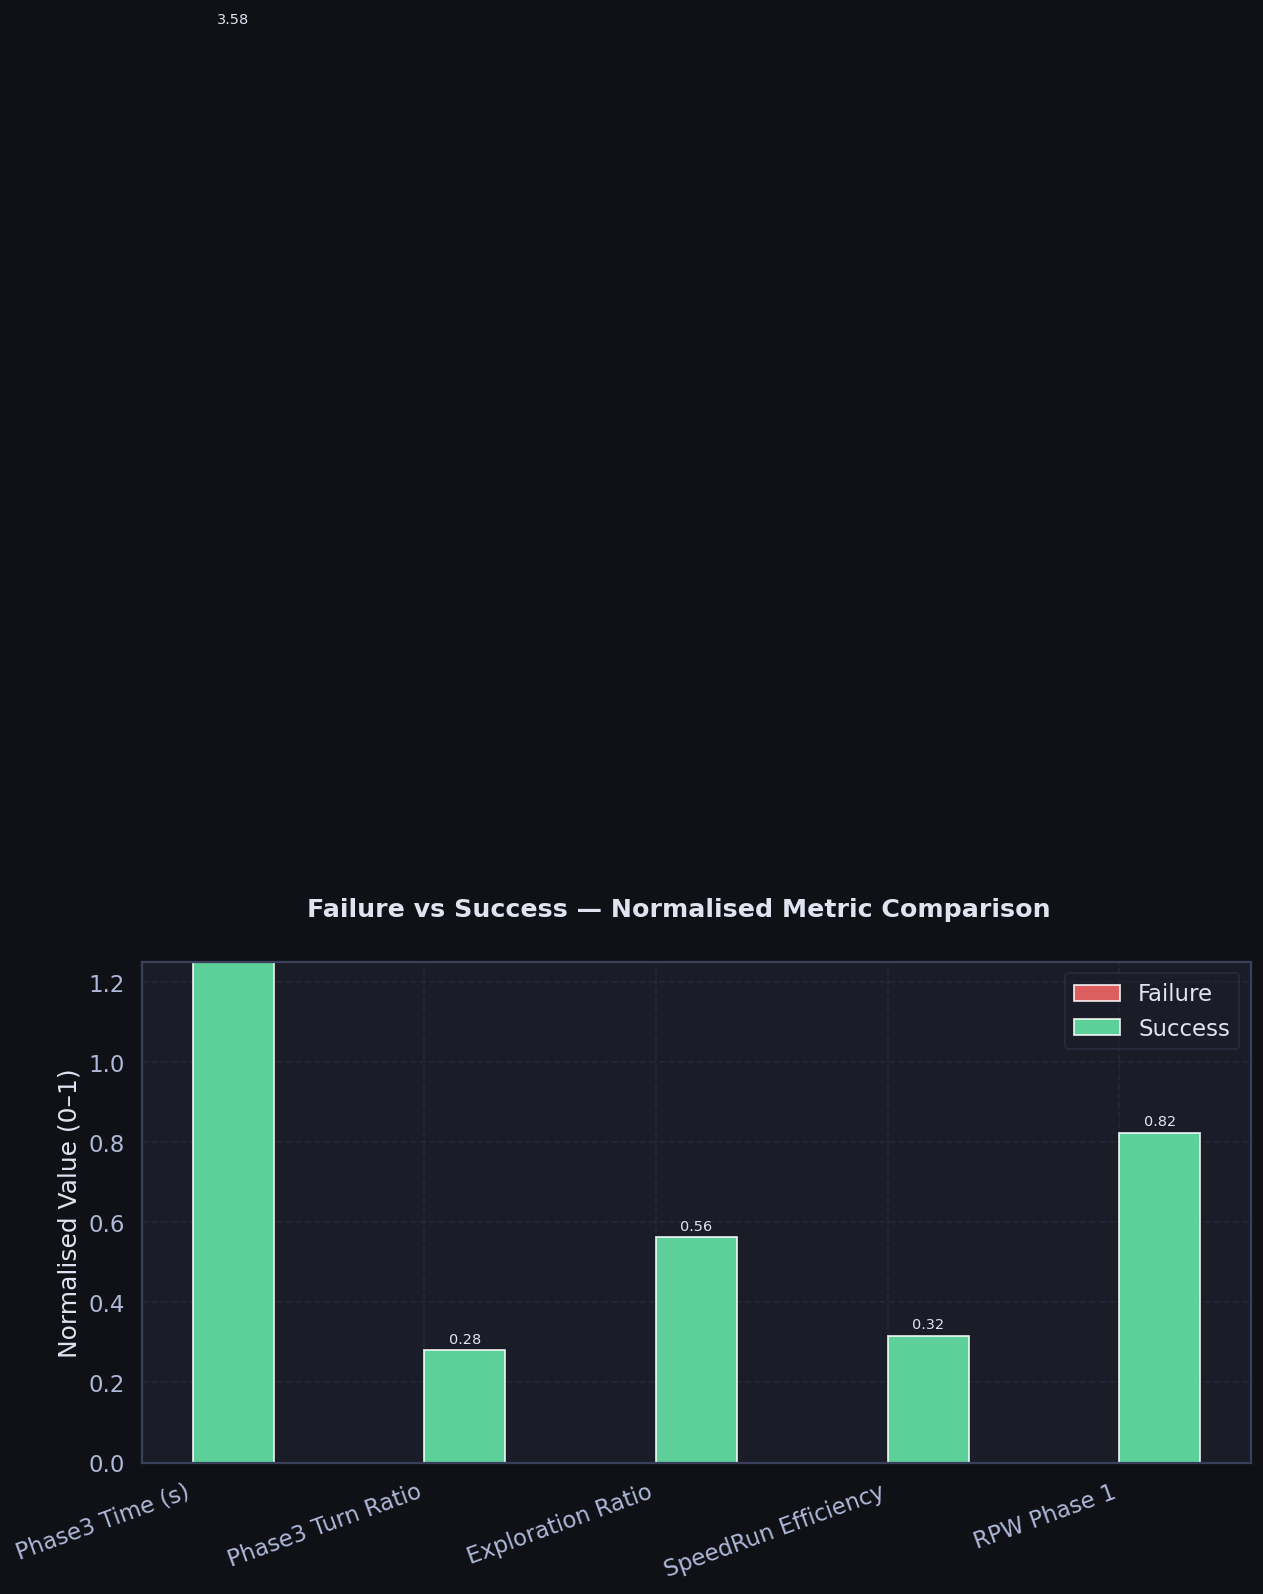

In [17]:
# ─── 7c  Comparative Radar / Bar: Failures vs Successes ──────────────────────
compare_metrics = {
    'p3_time_seconds': 'Phase3 Time (s)',
    'p3_turn_ratio': 'Phase3 Turn Ratio',
    'exploration_ratio': 'Exploration Ratio',
    'speedrun_efficiency': 'SpeedRun Efficiency',
    'rpw_phase1': 'RPW Phase 1',
}
compare_metrics = {k: v for k, v in compare_metrics.items() if k in df.columns}

comp_data = []
for label, subset in [('Failure', failures), ('Success', successes)]:
    row = {'outcome': label}
    for col in compare_metrics:
        row[compare_metrics[col]] = subset[col].mean() if col in subset.columns else np.nan
    comp_data.append(row)

comp_df = pd.DataFrame(comp_data).set_index('outcome')
print('\nMean metrics — Failures vs Successes:')
display(comp_df.round(4))

# ── Grouped bar chart ──
if len(comp_df.columns) > 0 and not comp_df.isna().all().all():
    # Normalise each metric 0-1 for comparison
    comp_norm = comp_df.copy()
    for col in comp_norm.columns:
        col_range = comp_norm[col].max() - comp_norm[col].min()
        if col_range > 0:
            comp_norm[col] = (comp_norm[col] - comp_norm[col].min()) / col_range

    fig, ax = plt.subplots(figsize=(11, 5))
    fig.suptitle('Failure vs Success — Normalised Metric Comparison', fontsize=14, fontweight='bold')

    x = np.arange(len(comp_norm.columns))
    width = 0.35
    colors = ['#ff6b6b', '#69f0ae']

    for i, (outcome, row) in enumerate(comp_norm.iterrows()):
        bars = ax.bar(x + (i - 0.5) * width, row.values, width,
                      label=outcome, color=colors[i], alpha=0.85, edgecolor='#ffffff20')
        for bar, val in zip(bars, row.values):
            if not np.isnan(val):
                ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                        f'{val:.2f}', ha='center', va='bottom', fontsize=8, color='#e0e4f0')

    ax.set_xticks(x)
    ax.set_xticklabels(comp_norm.columns, rotation=20, ha='right')
    ax.set_ylabel('Normalised Value (0–1)')
    ax.set_ylim(0, 1.25)
    ax.legend(framealpha=0.4)

    plt.tight_layout()
    plt.savefig('failure_profile.png', dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
    plt.show()

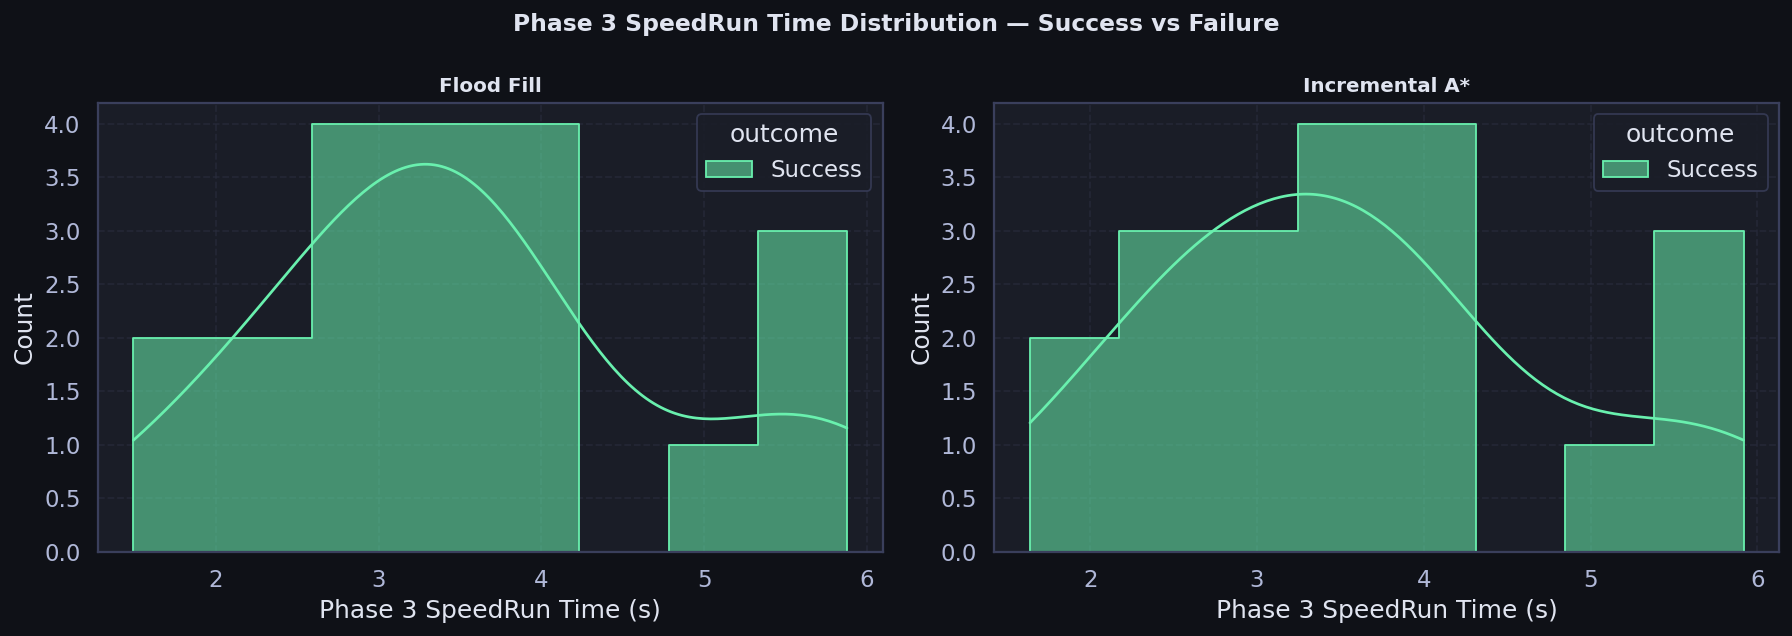

In [18]:
# ─── 7d  Phase 3 Time Distribution: Success vs Failure ───────────────────────
if 'p3_time_seconds' in df.columns:
    df['outcome'] = df['reached_goal'].map({True: 'Success', False: 'Failure'})

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Phase 3 SpeedRun Time Distribution — Success vs Failure',
                 fontsize=13, fontweight='bold')

    outcome_pal = {'Success': '#69f0ae', 'Failure': '#ff6b6b'}

    for i, alg in enumerate(ALG_ORDER):
        ax = axes[i]
        sub = df[df['algorithm'] == alg].dropna(subset=['p3_time_seconds'])
        if sub.empty:
            ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
            continue
        sns.histplot(
            data=sub, x='p3_time_seconds', hue='outcome',
            palette=outcome_pal, ax=ax, kde=True, bins=8,
            element='step', alpha=0.55
        )
        label = 'Flood Fill' if alg == 'FloodFill' else 'Incremental A*'
        ax.set_title(f'{label}', fontsize=11, fontweight='bold')
        ax.set_xlabel('Phase 3 SpeedRun Time (s)')
        ax.set_ylabel('Count')

    plt.tight_layout()
    plt.savefig('p3_time_distribution.png', dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
    plt.show()

---
## Section 8 — Bonus: Overall Algorithm Scorecard
A consolidated one-page summary comparing the two algorithms across all key metrics.

In [19]:
# ─── 8  Algorithm Scorecard ───────────────────────────────────────────────────
scorecard_metrics = [
    ('Success Rate (%)',        'reached_goal',          lambda s: s.mean() * 100),
    ('Avg Total Time (s)',      'elapsed_seconds',       'mean'),
    ('Avg Exploration Ratio',  'exploration_ratio',     'mean'),
    ('Avg SpeedRun Eff.',       'speedrun_efficiency',   'mean'),
    ('Avg P3 SpeedRun (s)',     'p3_time_seconds',       'mean'),
    ('Avg P1 Turn Ratio',       'p1_turn_ratio',         'mean'),
    ('Avg P3 Turn Ratio',       'p3_turn_ratio',         'mean'),
    ('RPW Overall (mean)',      'rpw_overall',           'mean'),
    ('RPW Phase 1 (mean)',      'rpw_phase1',            'mean'),
    ('Return Overhead (mean)',  'return_overhead_idx',   'mean'),
]

scorecard_rows = []
for label, col, agg in scorecard_metrics:
    if col not in df.columns:
        continue
    row = {'Metric': label}
    for alg in ALG_ORDER:
        sub = df[df['algorithm'] == alg][col].dropna()
        if callable(agg):
            val = agg(sub) if len(sub) > 0 else np.nan
        else:
            val = getattr(sub, agg)() if len(sub) > 0 else np.nan
        row[alg] = round(val, 4) if not np.isnan(val) else '—'
    scorecard_rows.append(row)

scorecard_df = pd.DataFrame(scorecard_rows).set_index('Metric')
scorecard_df.columns = ['Flood Fill', 'Incremental A*']

print('\n' + '='*60)
print('     🏆 ALGORITHM SCORECARD')
print('='*60)
display(scorecard_df)
print('\n✅ Analysis complete. All charts saved to current directory.')
print(f'   Data source: {DATA_SOURCE}')


     🏆 ALGORITHM SCORECARD


,Flood Fill,Incremental A*
Metric,,
Success Rate (%),100.0000,100.0000
Avg Total Time (s),25.8127,24.6325
Avg Exploration Ratio,0.5598,0.5648
Avg SpeedRun Eff.,0.3205,0.3140
Avg P3 SpeedRun (s),3.5638,3.5911
Avg P1 Turn Ratio,0.2880,0.3015
Avg P3 Turn Ratio,0.2817,0.2810
RPW Overall (mean),1.0000,0.6359
RPW Phase 1 (mean),1.0000,0.6485



✅ Analysis complete. All charts saved to current directory.
   Data source: ../logs/benchmark_20260610_105436.csv
